# 🚨 NLP-Based Crowd Detection System

**Goal:** Classify text messages as `CROWD_ALERT` (label=1) or `NORMAL` (label=0) using TF-IDF + Logistic Regression.

| Section | Description |
|---|---|
| 1 | Install & Import Libraries |
| 2 | Load Dataset |
| 3 | Text Preprocessing |
| 4 | TF-IDF Feature Extraction |
| 5 | Train/Test Split |
| 6 | Model Training |
| 7 | Evaluation |
| 8 | Prediction Function |
| 9 | Test Predictions |
| 10 | Save Model & Vectorizer |

---
## 📦 Section 1 — Install & Import Libraries

In [ ]:
# Install required libraries (already available in Colab, but kept for reproducibility)
!pip install pandas numpy scikit-learn matplotlib seaborn --quiet

In [ ]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model           import LogisticRegression
from sklearn.model_selection        import train_test_split
from sklearn.metrics                import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## 📂 Section 2 — Load Dataset

In [ ]:
# ── Upload your CSV via the Colab file upload widget, then update the path ──
# from google.colab import files
# uploaded = files.upload()   # ← uncomment to upload interactively

CSV_PATH = 'nlp_crowd_dataset.csv'   # ← update if needed

df = pd.read_csv(CSV_PATH)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}\n")
print("── First 5 rows ──")
display(df.head())

print("\n── Label distribution ──")
print(df['label'].value_counts().rename({1: 'CROWD_ALERT (1)', 0: 'NORMAL (0)'}))

Dataset shape : (400, 2)
Columns       : ['text', 'label']

── First 5 rows ──


,text,label
0,station is crowded,1
1,too much rush here,1
2,platform is full,1
3,heavy crowd at station,1
4,too many people here,1



── Label distribution ──
label
CROWD_ALERT (1)    200
NORMAL (0)         200
Name: count, dtype: int64


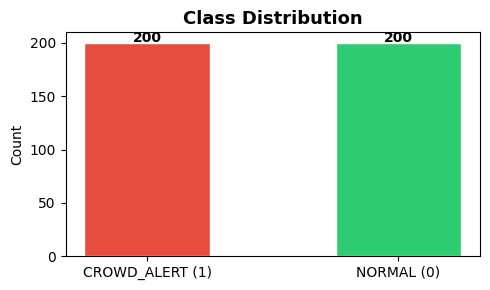

In [ ]:
# Visual check of class balance
fig, ax = plt.subplots(figsize=(5, 3))
counts = df['label'].value_counts()
ax.bar(['CROWD_ALERT (1)', 'NORMAL (0)'], counts.values,
       color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔧 Section 3 — Text Preprocessing

In [ ]:
def preprocess_text(text: str) -> str:
    """Lowercase → remove punctuation/special chars → strip extra spaces."""
    text = text.lower()                          # 1. lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)     # 2. keep only letters, digits, spaces
    text = re.sub(r'\s+', ' ', text).strip()    # 3. collapse extra whitespace
    return text

# Apply to the entire dataset
df['clean_text'] = df['text'].apply(preprocess_text)

print("── Sample before / after preprocessing ──")
sample = df[['text', 'clean_text']].head(6)
display(sample)

── Sample before / after preprocessing ──


,text,clean_text
0,station is crowded,station is crowded
1,too much rush here,too much rush here
2,platform is full,platform is full
3,heavy crowd at station,heavy crowd at station
4,too many people here,too many people here
5,crowd is increasing,crowd is increasing


---
## 🔢 Section 4 — TF-IDF Feature Extraction

In [ ]:
tfidf = TfidfVectorizer(
    max_features = 5000,      # vocabulary cap
    ngram_range  = (1, 2),    # unigrams + bigrams for richer context
    sublinear_tf = True       # apply log(1+tf) to dampen high-freq terms
)

X = tfidf.fit_transform(df['clean_text'])
y = df['label'].values

print(f"TF-IDF matrix shape : {X.shape}")
print(f"Vocabulary size     : {len(tfidf.vocabulary_)}")
print(f"Top 20 features     : {list(tfidf.get_feature_names_out()[:20])}")

TF-IDF matrix shape : (400, 75)
Vocabulary size     : 75
Top 20 features     : ['all', 'almost', 'almost empty', 'area', 'at', 'at all', 'at station', 'calm', 'calm place', 'crowd', 'crowd at', 'crowd here', 'crowd is', 'crowded', 'crowded platform', 'easy', 'easy to', 'empty', 'empty station', 'environment']


---
## ✂️ Section 5 — Train / Test Split (80 / 20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y        # preserve class ratio in both splits
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")

Training samples : 320
Test samples     : 80


---
## 🤖 Section 6 — Model Training (Logistic Regression)

In [ ]:
model = LogisticRegression(
    max_iter  = 200,
    C         = 1.0,      # regularisation strength (smaller = stronger)
    solver    = 'lbfgs',
    n_jobs    = -1
)

model.fit(X_train, y_train)
print("✅ Model trained successfully.")

✅ Model trained successfully.


---
## 📊 Section 7 — Evaluation

In [ ]:
y_pred = model.predict(X_test)

accuracy  = accuracy_score (y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score   (y_test, y_pred)
f1        = f1_score       (y_test, y_pred)

print("══════════════════════════════════════")
print("         MODEL EVALUATION REPORT      ")
print("══════════════════════════════════════")
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("══════════════════════════════════════")
print()
print("── Full Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['NORMAL', 'CROWD_ALERT']))

══════════════════════════════════════
         MODEL EVALUATION REPORT      
══════════════════════════════════════
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
══════════════════════════════════════

── Full Classification Report ──
              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        40
 CROWD_ALERT       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



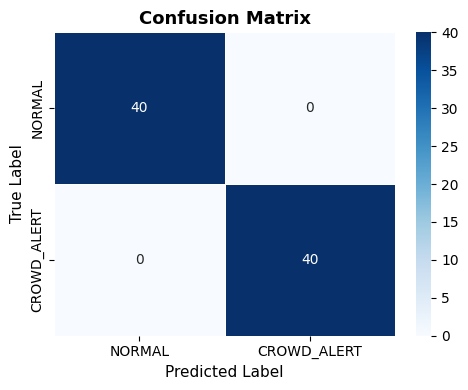

In [ ]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['NORMAL', 'CROWD_ALERT'],
    yticklabels=['NORMAL', 'CROWD_ALERT'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔮 Section 8 — Prediction Function

In [ ]:
def predict_message(text: str) -> str:
    """
    Predict whether a text message is crowd-related or normal.

    Parameters
    ----------
    text : str
        Raw user message.

    Returns
    -------
    str
        'CROWD_ALERT' if label == 1, else 'NORMAL'.
    """
    clean  = preprocess_text(text)          # Step 1: preprocess
    vector = tfidf.transform([clean])       # Step 2: TF-IDF transform
    label  = model.predict(vector)[0]       # Step 3: predict
    return 'CROWD_ALERT' if label == 1 else 'NORMAL'

print("✅ predict_message() is ready.")

✅ predict_message() is ready.


---
## 🧪 Section 9 — Test Predictions

In [ ]:
test_messages = [
    "station is crowded",
    "too much rush here",
    "platform is full",
    "station is empty",
    "vashi is to much crowd",
]

print(f"{'Message':<35} {'Prediction':<15}")
print("-" * 52)
for msg in test_messages:
    result = predict_message(msg)
    emoji  = '🚨' if result == 'CROWD_ALERT' else '✅'
    print(f"{msg:<35} {emoji} {result}")

Message                             Prediction     
----------------------------------------------------
station is crowded                  🚨 CROWD_ALERT
too much rush here                  🚨 CROWD_ALERT
platform is full                    🚨 CROWD_ALERT
station is empty                    ✅ NORMAL
vashi is to much crowd              🚨 CROWD_ALERT


---
## 💾 Section 10 — Save Model & Vectorizer

In [ ]:
import os

os.makedirs('crowd_model', exist_ok=True)

# Save with pickle
with open('crowd_model/model.pkl',      'wb') as f: pickle.dump(model, f)
with open('crowd_model/vectorizer.pkl', 'wb') as f: pickle.dump(tfidf, f)

print("✅ Saved:")
print("   crowd_model/model.pkl       ← Logistic Regression model")
print("   crowd_model/vectorizer.pkl  ← TF-IDF vectorizer")

✅ Saved:
   crowd_model/model.pkl       ← Logistic Regression model
   crowd_model/vectorizer.pkl  ← TF-IDF vectorizer


In [ ]:
# ── Verify reload works (e.g. for Flask integration) ─────────────────────────
with open('crowd_model/model.pkl',      'rb') as f: loaded_model = pickle.load(f)
with open('crowd_model/vectorizer.pkl', 'rb') as f: loaded_tfidf = pickle.load(f)

def predict_from_saved(text: str) -> str:
    """Standalone prediction using saved model + vectorizer (Flask-ready)."""
    clean  = preprocess_text(text)
    vector = loaded_tfidf.transform([clean])
    label  = loaded_model.predict(vector)[0]
    return 'CROWD_ALERT' if label == 1 else 'NORMAL'

# Quick smoke-test
print(predict_from_saved("massive crowd at the gate"))  # → CROWD_ALERT
print(predict_from_saved("everything is calm today"))   # → NORMAL
print("✅ Reload verified — model is Flask-ready.")

CROWD_ALERT
NORMAL
✅ Reload verified — model is Flask-ready.


---
## 🌐 Flask Integration Snippet (reference only)

```python
# app.py
from flask import Flask, request, jsonify
import pickle, re

app = Flask(__name__)

with open('crowd_model/model.pkl',      'rb') as f: model = pickle.load(f)
with open('crowd_model/vectorizer.pkl', 'rb') as f: tfidf = pickle.load(f)

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

@app.route('/predict', methods=['POST'])
def predict():
    data   = request.get_json(force=True)
    text   = data.get('text', '')
    clean  = preprocess_text(text)
    vector = tfidf.transform([clean])
    label  = model.predict(vector)[0]
    result = 'CROWD_ALERT' if label == 1 else 'NORMAL'
    return jsonify({'text': text, 'prediction': result})

if __name__ == '__main__':
    app.run(debug=True)
```

> **Usage:**  
> `curl -X POST http://127.0.0.1:5000/predict -H 'Content-Type: application/json' -d '{"text": "platform is packed"}'`